# Survey ↔ Vote Matching Pipeline

End-to-end pipeline: **embed → match → enrich dates → simplify**

In [1]:
from pathlib import Path
from eu_survey_correlation.embeddings.date_utils import (
    build_survey_date_mapping,
    resolve_survey_date,
)

import pandas as pd

# ── Config ────────────────────────────────────────────────────────────
DATA_DIR = Path("data")

SURVEY_CSV = DATA_DIR / "surveys" / "michlou_survey_tri.csv"
VOTE_SUMMARIES_CSV = DATA_DIR / "votes" / "vote_summaries.csv"
VOTES_CSV = DATA_DIR / "votes" / "votes.csv"

EMBEDDING_CACHE = DATA_DIR / "cache" / "embeddings.parquet"

SIMPLIFIER_CACHE = DATA_DIR / "cache" / "simplified_text.json"
OUTPUT_CSV = DATA_DIR / "matches" / "simplified_michlou_survey_vote_matches_clean.csv"

TOP_K = 3
THRESHOLD = 0.0

/Users/ugo/Documents/MH2D_projets/dawta/eu_survey_correlation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

In [2]:
surveys = (
    pd.read_csv(SURVEY_CSV)
    .dropna(subset=["question_en"])
    .drop_duplicates(subset=["question_en"])
)
vote_summaries = (
    pd.read_csv(VOTE_SUMMARIES_CSV)
    .dropna(subset=["summary"])
    .drop_duplicates(subset=["vote_id"])
)
print(f"Surveys: {len(surveys)} | Vote summaries: {len(vote_summaries)}")

Surveys: 115 | Vote summaries: 2205


## 2. Simplify questions and votes

In [3]:
from eu_survey_correlation.simplifier import Simplifier

simplifier = Simplifier(cache_path=SIMPLIFIER_CACHE)

# Skip if question_clean already present in input CSV
surveys = simplifier.simplify_dataframe(
    surveys,
    text_column="question_en",
    output_column="question_clean",
    prompt_template=Simplifier.SURVEY_QUESTION_PROMPT,
    save_path=SURVEY_CSV,
)
print(len(surveys))
surveys = surveys.drop_duplicates(subset=["question_clean"])
print(len(surveys))

2026-03-08 12:37:42.901 | INFO     | eu_survey_correlation.simplifier:__init__:74 - Loaded 1726 cached simplifications from data/cache/simplified_text.json
2026-03-08 12:37:42.902 | INFO     | eu_survey_correlation.simplifier:simplify_dataframe:179 - Cache hit for 115/115 rows
2026-03-08 12:37:42.903 | SUCCESS  | eu_survey_correlation.simplifier:simplify_dataframe:182 - All 115 rows served from cache


115
107


In [ ]:
DISTRIBUTIONS_META = DATA_DIR / "surveys" / "distributions_metadata.json"

date_mapping = build_survey_date_mapping(DISTRIBUTIONS_META)
surveys["survey_date"] = pd.to_datetime(
    surveys["file_name"].apply(lambda f: resolve_survey_date(str(f), date_mapping))
)

In [11]:
# Skip if question_clean already present in input CSV
vote_summaries = simplifier.simplify_dataframe(
    vote_summaries,
    text_column="summary",
    output_column="summary_clean",
    prompt_template=Simplifier.VOTE_SUMMARY_PROMPT,
    save_path=VOTE_SUMMARIES_CSV,
)
print(len(vote_summaries))
vote_summaries = vote_summaries.drop_duplicates(subset=["summary_clean"])
print(len(vote_summaries))

2026-03-08 12:38:25.717 | INFO     | eu_survey_correlation.simplifier:simplify_dataframe:179 - Cache hit for 1611/1611 rows
2026-03-08 12:38:25.718 | SUCCESS  | eu_survey_correlation.simplifier:simplify_dataframe:182 - All 1611 rows served from cache


1611
1611


In [12]:
votes_full = pd.read_csv(VOTES_CSV)
votes_full["vote_date"] = pd.to_datetime(
    votes_full["timestamp"], format="%d/%m/%Y %H:%M", errors="coerce"
)
vote_date_map = dict(zip(votes_full["id"], votes_full["vote_date"]))

vote_summaries["vote_date"] = vote_summaries["vote_id"].map(vote_date_map)

## 2. Embed surveys & votes

In [13]:
from eu_survey_correlation.embeddings import Embedder

embedder = Embedder(cache_path=EMBEDDING_CACHE)

survey_emb_df = embedder.embed_dataframe(surveys, text_column="question_clean")
vote_emb_df = embedder.embed_dataframe(vote_summaries, text_column="summary_clean")
print(
    f"Survey embeddings: {survey_emb_df.shape} | Vote embeddings: {vote_emb_df.shape}"
)

2026-03-08 12:38:27.245 | INFO     | eu_survey_correlation.embeddings.embedder:__init__:33 - Loading SentenceTransformer model 'all-MiniLM-L6-v2'...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1646.42it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 12:38:29.444 | SUCCESS  | eu_survey_correlation.embeddings.embedder:__init__:35 - Model 'all-MiniLM-L6-v2' loaded (dim=384)
2026-03-08 12:38:29.468 | INFO     | eu_survey_correlation.embeddings.embedder:__init__:41 - Loaded embedding cache: 9612 rows from data/cache/embeddings.parquet
2026-03-08 12:38:29.509 | INFO     | eu_survey_correlation.embeddings.embedder:embed_dataframe:99 

Survey embeddings: (107, 391) | Vote embeddings: (1611, 388)


## 4. Match pairs

In [28]:
from eu_survey_correlation.embeddings import PairMatcher

matcher = PairMatcher(survey_embeddings=survey_emb_df, vote_embeddings=vote_emb_df)
matches = matcher.match(top_k=TOP_K, threshold=THRESHOLD)
matches["time_delta"] = (matches["vote_date"] - matches["survey_date"]).dt.days
print(f"Raw matches: {len(matches)}")

2026-03-08 12:40:58.579 | SUCCESS  | eu_survey_correlation.embeddings.pair_matcher:__init__:48 - Loaded 107 survey and 1611 vote embeddings (dim=384)
2026-03-08 12:40:58.580 | INFO     | eu_survey_correlation.embeddings.pair_matcher:match:80 - Computing matches (top_k=3, threshold=0.0, batch_size=256, vote_after_survey=True)...
Computing matches: 100%|██████████| 1/1 [00:16<00:00, 16.08s/it]
2026-03-08 12:41:14.664 | INFO     | eu_survey_correlation.embeddings.pair_matcher:match:139 - Found 321 matches above threshold 0.0


Raw matches: 321


## 7. Save results

In [30]:
# Select and rename final columns
output_cols = [
    "sheet_id",
    "question_clean",
    "question_en",
    "file_name",
    "survey_date",
    "vote_id",
    "summary",
    "summary_clean",
    "vote_date",
    "similarity_score",
    "time_delta",
]
# Keep only columns that exist
output_cols = [c for c in output_cols if c in matches.columns]
result = matches[output_cols].sort_values("similarity_score", ascending=False)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
result.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(result)} matches → {OUTPUT_CSV}")

Saved 321 matches → data/matches/simplified_michlou_survey_vote_matches_clean.csv


## 8. Explore results

Total matches: 321
Unique questions: 93
Unique votes: 178

Similarity stats:
count    321.000000
mean       0.485159
std        0.099088
min        0.205256
25%        0.409138
50%        0.513690
75%        0.557329
max        0.665034
Name: similarity_score, dtype: float64

Time delta stats (days):
count     321.000000
mean      651.676012
std       485.744841
min         1.000000
25%       301.000000
50%       581.000000
75%       889.000000
max      2247.000000
Name: time_delta, dtype: float64


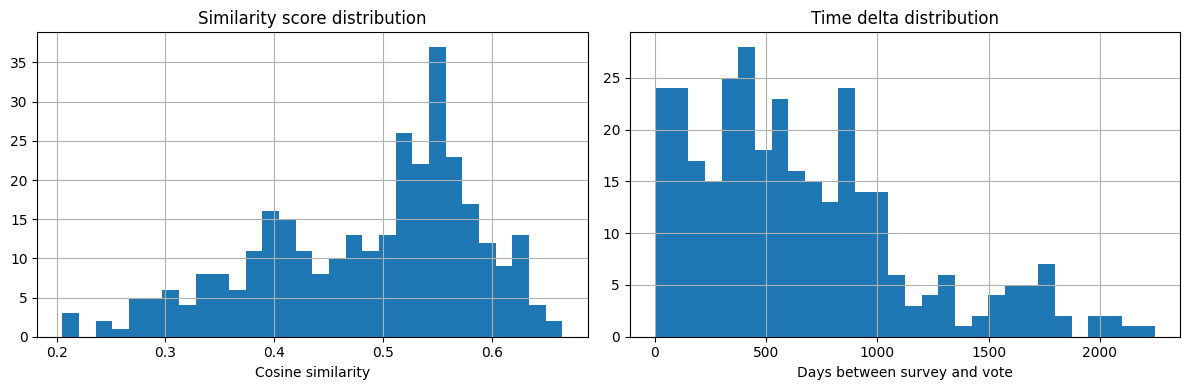

In [31]:
import matplotlib.pyplot as plt

print(f"Total matches: {len(result)}")
print(f"Unique questions: {result['sheet_id'].nunique()}")
print(f"Unique votes: {result['vote_id'].nunique()}")
print(f"\nSimilarity stats:\n{result['similarity_score'].describe()}")
print(f"\nTime delta stats (days):\n{result['time_delta'].describe()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
result["similarity_score"].hist(bins=30, ax=axes[0])
axes[0].set_title("Similarity score distribution")
axes[0].set_xlabel("Cosine similarity")

result["time_delta"].hist(bins=30, ax=axes[1])
axes[1].set_title("Time delta distribution")
axes[1].set_xlabel("Days between survey and vote")
plt.tight_layout()
plt.show()

In [32]:
# Top matches
for _, row in result.head(10).iterrows():
    q = row.get("question_clean", row.get("question_en", ""))
    v = row.get("summary_clean", row.get("summary", ""))
    print(f"Survey:  {q}")
    print(f"Vote:    {v}")
    print(
        f"Score:   {row['similarity_score']:.3f}  |  Δt: {row.get('time_delta', '?')} days"
    )
    print()

Survey:  Should more or less decision-making for protecting the environment and reducing climate change occur at the European level? (M)
Vote:    The European Parliament voted to approve a plan requiring all EU countries to reduce greenhouse gas emissions by 2030 compared to 2005 levels. The reduction targets for each member state will be based on GDP per capita and cost-effectiveness, with limited possibilities for emissions trading, borrowing, and saving. Additionally, there will be increased transparency, with national actions regarding emissions to be made public.
Score:   0.665  |  Δt: 743 days

Survey:  Which products, considering children's need for healthy diets, should be distributed through the EU school scheme? (Multiple answers possible)
Vote:    The European Parliament passed a resolution, with majority support, to enhance nutrition education for promoting healthy diets as a preventive measure against childhood obesity in the EU.
Score:   0.660  |  Δt: 377 days

Survey:  D